### Notebook 25

# **Multi-Channel Tables and Figures**

## **1. Tables**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import pickle

In [2]:
# Define the results path. 
results_path = '../neuropolis-x1_results/'

In [3]:
# Load the general results. 
with open(results_path + 'general_results.p', 'rb') as file:
    general_results = pickle.load(file)

# Store the results into variables. 
df_summary_foundation_models = general_results['df_summary_foundation_models']
df_summary_mcnemars = general_results['df_summary_mcnemars']
dict_mcnemars_p_values = general_results['dict_mcnemars_p_values']

# Load the general results for the multi-channel experiment. 
with open(results_path + 'multi-channel/general_results.p', 'rb') as file:
    general_results = pickle.load(file)

# Store the results into variables. 
df_summary_multi_channel_foundation_models = general_results['df_summary_foundation_models']
df_summary_multi_channel_mcnemars = general_results['df_summary_mcnemars']
dict_multi_channel_mcnemars_p_values = general_results['dict_mcnemars_p_values']
df_summary_wilcoxon_multi_channel = general_results['df_summary_wilcoxon_multi_channel']

# Add the 'Gemma 5-Channel' results to the main summary DataFrame and the McNemar's summary DataFrame. 
df_summary_foundation_models = pd.concat([df_summary_foundation_models,
                                          df_summary_multi_channel_foundation_models.loc[['Gemma 5-Channel'], :]])
df_summary_mcnemars = pd.concat([df_summary_mcnemars,
                                 df_summary_multi_channel_mcnemars.loc[['Gemma 5-Channel'], :]])

# Add the 'Gemma 5-Channel' results to the McNemar's p-values dictionary. 
dict_mcnemars_p_values['Gemma 5-Channel'] = dict_multi_channel_mcnemars_p_values['Gemma 5-Channel']


In [4]:
# Define a function to format the summary DataFrame. 
def format_df_summary(df_summary, score_type):

    # Copy the DataFrame. 
    df_summary_table = df_summary.copy()
    
    # Round values to 3 decimal places. 
    df_summary_table['mean model ' + score_type] = df_summary_table['mean model ' + score_type].astype(float).round(3)
    df_summary_table['mean baseline ' + score_type] = df_summary_table['mean baseline ' + score_type].astype(float).round(3)
    df_summary_table['STD model ' + score_type] = df_summary_table['STD model ' + score_type].astype(float).round(3)
    df_summary_table['STD baseline ' + score_type] = df_summary_table['STD baseline ' + score_type].astype(float).round(3)
    df_summary_table['CI (lower)'] = df_summary_table['CI (lower)'].astype(float).round(3)
    df_summary_table['CI (upper)'] = df_summary_table['CI (upper)'].astype(float).round(3)
    df_summary_table['RBC'] = df_summary_table['RBC'].astype(float).round(3)
    df_summary_table['CLES'] = df_summary_table['CLES'].astype(float).round(3)

    # Create new columns. 
    df_summary_table['model ' + score_type] = df_summary_table['mean model ' + score_type].astype(str) + ' ± ' + df_summary_table['STD model ' + score_type].astype(str)
    df_summary_table['baseline ' + score_type] = df_summary_table['mean baseline ' + score_type].astype(str) + ' ± ' + df_summary_table['STD baseline ' + score_type].astype(str)
    df_summary_table['confidence interval'] = df_summary_table['CI (lower)'].astype(str) + ' - ' + df_summary_table['CI (upper)'].astype(str)

    # Display only the relevant columns.
    df_summary_table = df_summary_table[['N', 'model ' + score_type, 'baseline ' + score_type, 'p-value', 'confidence interval', 'RBC', 'CLES']]
    
    return df_summary_table

In [5]:
# Format the DataFrame. 
df_summary_class_table = format_df_summary(df_summary_foundation_models, 'accuracy')

# Replace the indexes with model name abbreviations. 
model_names = df_summary_class_table.index.tolist()
model_abbreviations_fm = ['Gemma', 'Llama', 'Gemma CoT', 'Gemma without FT', 'Gemma with FT', 'PaliGemma', 'Gemma 5-Channel']
df_summary_class_table.index = model_abbreviations_fm

# Save the DataFrame. 
df_summary_class_table.to_csv(results_path + 'table_foundation_models_wilcoxon.csv', index = True)

# Display the DataFrame. 
print('Foundation Models: Wilcoxon Test')
df_summary_class_table

Foundation Models: Wilcoxon Test


,N,model accuracy,baseline accuracy,p-value,confidence interval,RBC,CLES
Gemma,72,0.534 ± 0.106,0.528 ± 0.038,1.82e-01,0.509 - 0.558,0.123,0.555
Llama,72,0.51 ± 0.129,0.531 ± 0.037,8.57e-01,0.479 - 0.539,-0.145,0.456
Gemma CoT,45,0.545 ± 0.117,0.533 ± 0.041,1.88e-01,0.51 - 0.579,0.154,0.573
Gemma without FT,45,0.545 ± 0.116,0.533 ± 0.039,1.42e-01,0.512 - 0.579,0.184,0.555
Gemma with FT,45,0.547 ± 0.133,0.534 ± 0.046,1.36e-01,0.508 - 0.585,0.190,0.549
PaliGemma,72,0.477 ± 0.142,0.584 ± 0.12,1.00e+00,0.445 - 0.509,-0.540,0.310
Gemma 5-Channel,72,0.503 ± 0.118,0.53 ± 0.041,9.67e-01,0.476 - 0.53,-0.250,0.387


In [6]:
# Format the DataFrame for the results of the McNemar's tests. 
df_summary_mcnemars_table = df_summary_mcnemars.copy()

# Round values to 3 decimal places and format the p-values in scientific notation. 
df_summary_mcnemars_table['model accuracy'] = df_summary_mcnemars_table['model accuracy'].astype(float).round(3)
df_summary_mcnemars_table['baseline accuracy'] = df_summary_mcnemars_table['baseline accuracy'].astype(float).round(3)
df_summary_mcnemars_table['combined p-value'] = df_summary_mcnemars_table['combined p-value'].astype(float).round(3).apply(lambda x: f'{x:.2e}')
df_summary_mcnemars_table['median p-value'] = df_summary_mcnemars_table['median p-value'].astype(float).round(3).apply(lambda x: f'{x:.2e}')
df_summary_mcnemars_table['proportion p-value < 0.05'] = df_summary_mcnemars_table['proportion p-value < 0.05'].astype(float).round(3)

# Drop the combined statistics column. 
df_summary_mcnemars_table = df_summary_mcnemars_table.drop(columns = ['combined statistic'])

# Replace the indexes with model name abbreviations. 
df_summary_mcnemars_table.index = model_abbreviations_fm

# Save the DataFrame. 
df_summary_mcnemars_table.to_csv(results_path + 'table_foundation_models_mcnemars.csv', index = True)

# Display the DataFrame. 
print('Foundation Models: McNemar\'s Test')
df_summary_mcnemars_table

Foundation Models: McNemar's Test


,N,model accuracy,baseline accuracy,combined p-value,median p-value,proportion p-value < 0.05
Gemma,1386,0.535,0.505,0.00e+00,1.21e-01,0.288
Llama,1326,0.508,0.505,1.00e+00,6.61e-01,0.005
Gemma CoT,858,0.544,0.510,0.00e+00,1.55e-01,0.229
Gemma without FT,870,0.545,0.511,0.00e+00,1.54e-01,0.228
Gemma with FT,867,0.547,0.512,0.00e+00,1.44e-01,0.244
PaliGemma,670,0.479,0.509,0.00e+00,3.08e-01,0.086
Gemma 5-Channel,1327,0.501,0.506,1.00e+00,6.39e-01,0.007


## **2. Figures**

In [7]:
# Set the style of the plots. 
plt.rcParams.update({'font.family': 'serif'})

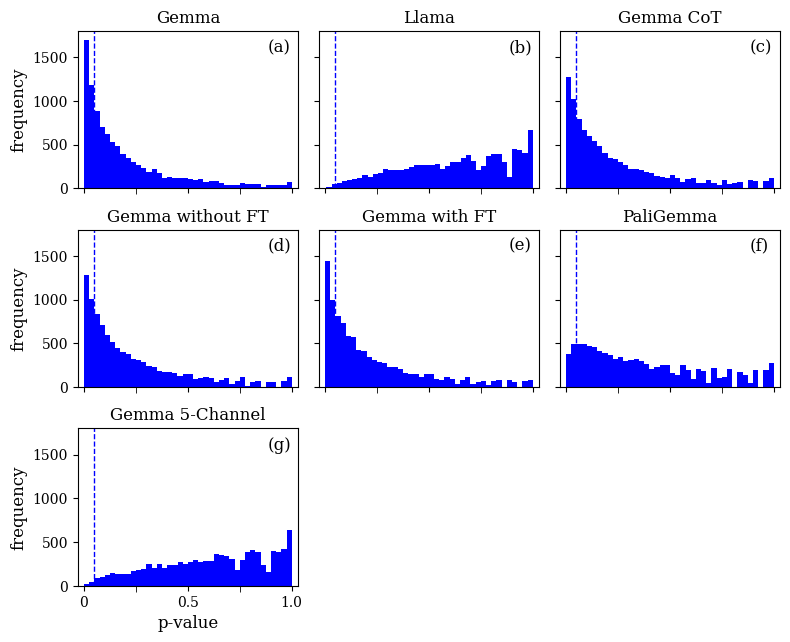

In [8]:
# Plot the distribution of p-values for all foundation models. 
fig, axes = plt.subplots(3, 3, figsize = (8, 7), sharex = True, sharey = True)
#fig.suptitle('Foundation Models: Distribution of p-values', fontsize = 13)

# Iterate through all foundation models. 
for model_index, model_name in enumerate(model_names):
    ax = axes[model_index // 3, model_index % 3]
    ax.hist(dict_mcnemars_p_values[model_name], bins = 40, color = 'blue')
    #ax.set_title(model_name, fontsize = 12)
    ax.set_title(model_abbreviations_fm[model_index], fontsize = 12)
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(0, 1800)
    ax.set_xticks([0, 0.5, 1.0], minor = False)
    ax.set_xticks([0.25, 0.75], minor = True)
    ax.tick_params(axis = 'x', which = 'minor', length = 4)
    ax.set_xticklabels(['0', '0.5', '1.0'], minor = False, fontsize = 10)

    ax.axvline(0.05, linestyle = '--', linewidth = 1, color = 'blue')
    ax.text(0.86, 0.95, f'({chr(97 + model_index)})',
            transform = ax.transAxes,
            va = 'top', ha = 'left', fontsize = 12)

# Display outer labels only. 
axes[2, 0].set_xlabel('p-value', fontsize = 12)
# axes[1, 1].set_xlabel('p-value', fontsize = 12)
# axes[1, 2].set_xlabel('p-value', fontsize = 12)
axes[0, 0].set_ylabel('frequency', fontsize = 12)
axes[1, 0].set_ylabel('frequency', fontsize = 12)
axes[2, 0].set_ylabel('frequency', fontsize = 12)

# Hide the last two empty subplots. 
axes[2, 1].axis('off')
axes[2, 2].axis('off')

# Adjust the layout of the subplots. 
plt.tight_layout()
plt.subplots_adjust(top = 0.88)

# Save the figure. 
fig.savefig(results_path + 'figure_foundation_models.pdf', format = 'pdf', bbox_inches = 'tight')